In [15]:
import numpy as np
import pandas as pd
import yfinance as yf
import warnings
import cvxpy as cp
import math
import random
from collections import defaultdict
from scipy.stats import kurtosis
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
np.random.seed(42)
random.seed(42)

# === 1. Tickers y sectores de 10 empresas del IBEX 35 seleccionadas (2015)
TICKERS = {
    "SAN.MC": "Financiero", "BBVA.MC": "Financiero", "ITX.MC": "Consumo Discrecional",
    "IBE.MC": "Energía Eléctrica", "REP.MC": "Energía (Petróleo y Gas)",
    "TEF.MC": "Telecomunicaciones", "ACS.MC": "Construcción",
    "FER.MC": "Construcción", "GRF.MC": "Salud", "AMS.MC": "Tecnología"
}
tickers = list(TICKERS.keys())

# === 2. Descargar precios para todo el período 2012–2015
data = yf.download(tickers, start="2012-01-01", end="2015-12-31", auto_adjust=True)["Close"]

# === 3. Calcular retornos diarios para todo el período
returns = data.pct_change().dropna()

# === 4. Usar todo 2015 para entrenamiento y prueba
returns_2015 = returns.loc["2015-01-01":"2015-12-31"]
mean_2015 = returns_2015.mean() * 252
cov_2015 = returns_2015.cov() * 252

# === 9. Algoritmo Genético - Definición de variables y funciones
MAX_VOL = 0.20
RISK_FREE_RATE = 0.03
POP, GEN, MUT_RATE = 100, 200, 0.10

def base_penalty(w):
    pen = abs(w.sum() - 1) * 1e3  # Solo penalizar si los pesos no suman 1
    return pen

def metr_ga(w, returns_df, mean_series, cov_df):
    r = (mean_series) @ w
    v = math.sqrt(w @ (cov_df).values @ w)
    s = (r - RISK_FREE_RATE) / v if v > 0 else 0
    c = -np.sort(returns_df @ w)[:int(0.05*len(returns_df))].mean()
    h = (w**2).sum()
    k = kurtosis(returns_df @ w)
    return r, v, s, c, h, k

# === 10. AG Multiobjetivo (Maximizar Retorno, Minimizar CVaR, Minimizar Volatilidad, Minimizar Kurtosis) ===
class PortfolioProblem(ElementwiseProblem):
    def __init__(self):
        super().__init__(
            n_var=len(tickers),
            n_obj=4,  # Cuatro objetivos: retorno, CVaR, volatilidad y kurtosis
            n_constr=1,  # Una restricción para la volatilidad máxima
            xl=np.zeros(len(tickers)),
            xu=np.ones(len(tickers))
        )

    def _evaluate(self, w, out, *args, **kwargs):
        # Normalizar pesos para que sumen 1
        if w.sum() == 0:
            w = np.ones(len(w)) / len(w)
        else:
            w = w / w.sum()

        # Objetivos
        mu_w = w @ mean_2015.values  # Retorno esperado (maximizar)
        cvar_w = -np.sort(returns_2015 @ w)[:int(0.05 * len(returns_2015))].mean()  # CVaR (minimizar)
        sig_w = math.sqrt(w @ cov_2015.values @ w)  # Volatilidad (minimizar)
        kurt_w = kurtosis(returns_2015 @ w)  # Kurtosis (minimizar)

        # Penalización por restricciones
        penalty = base_penalty(w)

        # Restricción de volatilidad máxima
        vol_constraint = sig_w - MAX_VOL  # Debe ser <= 0 para cumplir la restricción

        # Ajustar objetivos con penalización
        out["F"] = [
            -mu_w + penalty,  # Negativo porque pymoo minimiza por defecto
            cvar_w + penalty,  # CVaR (minimizar)
            sig_w + penalty,   # Volatilidad (minimizar)
            kurt_w + penalty   # Kurtosis (minimizar)
        ]
        # Agregar restricción de volatilidad
        out["G"] = [vol_constraint]

# Ejecutar AG multiobjetivo con NSGA-II
print("Ejecutando AG Multiobjetivo (Max Retorno, Min CVaR, Min Volatilidad, Min Kurtosis)...")
problem = PortfolioProblem()
algorithm = NSGA2(pop_size=100)
res = minimize(
    problem,
    algorithm,
    ('n_gen', 200),
    seed=42,
    verbose=False
)

# Seleccionar una solución del frente de Pareto (la de mejor Sharpe)
pareto_weights = res.X
sharpe_ratios = []
for w in pareto_weights:
    if w.sum() == 0:
        w = np.ones(len(w)) / len(w)
    else:
        w = w / w.sum()
    r = (mean_2015) @ w
    v = math.sqrt(w @ (cov_2015).values @ w)
    s = (r - RISK_FREE_RATE) / v if v > 0 else 0
    sharpe_ratios.append(s)

best_idx = np.argmax(sharpe_ratios)
best_multi_weights = pareto_weights[best_idx]
if best_multi_weights.sum() == 0:
    best_multi_weights = np.ones(len(best_multi_weights)) / len(best_multi_weights)
else:
    best_multi_weights = best_multi_weights / best_multi_weights.sum()

# Calcular métricas para la solución seleccionada
ret_multi, vol_multi, sharpe_multi, cvar_multi, herf_multi, kurt_multi = metr_ga(
    best_multi_weights, returns_2015, mean_2015, cov_2015
)

# === Crear tabla comparativa
data_comp = {
    "Modelo": ["AG (Multiobjetivo)"],
    "Retorno 2015": [ret_multi],
    "Volatilidad 2015": [vol_multi],
    "Sharpe Ratio": [sharpe_multi],
    "CVaR 95%": [cvar_multi],
    "Herfindahl": [herf_multi],
    "Kurtosis": [kurt_multi]
}

df_comparison = pd.DataFrame(data_comp)

# Reemplazar NaN por cadenas vacías
df_comparison = df_comparison.fillna("")

# Formatear e imprimir la tabla
def format_float(x):
    try:
        return f'{float(x):.4f}'
    except ValueError:
        return x

formatted_df = df_comparison.copy()
for col in ["Retorno 2015", "Volatilidad 2015", "Sharpe Ratio", "CVaR 95%", "Herfindahl", "Kurtosis"]:
    formatted_df[col] = formatted_df[col].apply(format_float)

print(formatted_df.to_string(index=False))

[*********************100%***********************]  10 of 10 completed


Ejecutando AG Multiobjetivo (Max Retorno, Min CVaR, Min Volatilidad, Min Kurtosis)...
            Modelo Retorno 2015 Volatilidad 2015 Sharpe Ratio CVaR 95% Herfindahl Kurtosis
AG (Multiobjetivo)       0.2945           0.1916       1.3803   0.0262     0.3164   0.3071


In [18]:
# Crear DataFrame con los pesos óptimos y los nombres de los activos
pesos_df = pd.DataFrame({
    "Ticker": tickers,
    "Peso (%)": w * 100
})

# Redondear a 2 decimales para que sea más legible
pesos_df["Peso (%)"] = pesos_df["Peso (%)"].round(2)

# Mostrar
print(pesos_df)

    Ticker  Peso (%)
0   SAN.MC      0.00
1  BBVA.MC     15.38
2   ITX.MC      0.02
3   IBE.MC     40.62
4   REP.MC      3.04
5   TEF.MC     40.75
6   ACS.MC      0.04
7   FER.MC      0.00
8   GRF.MC      0.00
9   AMS.MC      0.15


[*********************100%***********************]  10 of 10 completed


Ejecutando AG Multiobjetivo (Max Retorno, Min CVaR, Min Kurtosis con Volatilidad Fija)...
            Modelo Retorno 2015 Volatilidad 2015 Sharpe Ratio CVaR 95% Herfindahl Kurtosis
AG (Multiobjetivo)       0.2945           0.1916       1.3800                             


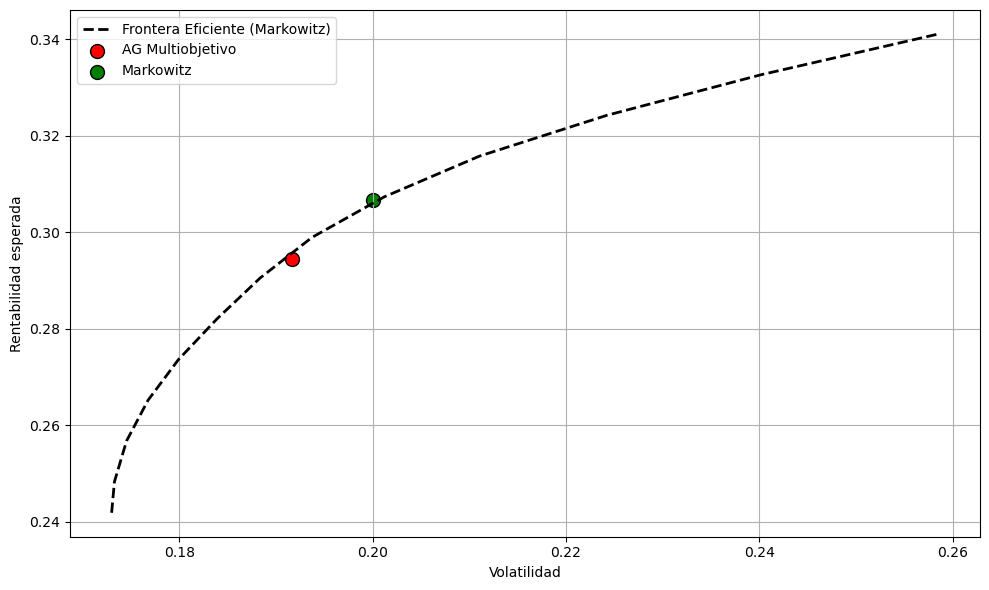

In [19]:
import numpy as np
import pandas as pd
import yfinance as yf
import warnings
import math
from collections import defaultdict
from scipy.stats import kurtosis
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
import cvxpy as cp
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
np.random.seed(42)
random.seed(42)

# === 1. Tickers y sectores de 10 empresas del IBEX 35 seleccionadas (2015)
TICKERS = {
    "SAN.MC": "Financiero", "BBVA.MC": "Financiero", "ITX.MC": "Consumo Discrecional",
    "IBE.MC": "Energía Eléctrica", "REP.MC": "Energía (Petróleo y Gas)",
    "TEF.MC": "Telecomunicaciones", "ACS.MC": "Construcción",
    "FER.MC": "Construcción", "GRF.MC": "Salud", "AMS.MC": "Tecnología"
}
tickers = list(TICKERS.keys())

# === 2. Descargar precios para todo el período 2012–2015
data = yf.download(tickers, start="2012-01-01", end="2015-12-31", auto_adjust=True)["Close"]

# === 3. Calcular retornos diarios para todo el período
returns = data.pct_change().dropna()

# === 4. Usar todo 2015 para entrenamiento y prueba
returns_2015 = returns.loc["2015-01-01":"2015-12-31"]
mean_2015 = returns_2015.mean() * 252
cov_2015 = returns_2015.cov() * 252
mu_2015 = mean_2015.values
Sigma_2015 = cov_2015.values
n_tickers = len(mu_2015)

# === 9. Algoritmo Genético - Definición de variables y funciones
MAX_VOL = 0.20
RISK_FREE_RATE = 0.03
POP, GEN, MUT_RATE = 100, 200, 0.10

def base_penalty(w):
    pen = abs(w.sum() - 1) * 1e3  # Solo penalizar si los pesos no suman 1
    return pen

def metr_ga(w, returns_df, mean_series, cov_df):
    r = (mean_series) @ w
    v = math.sqrt(w @ (cov_df).values @ w)
    s = (r - RISK_FREE_RATE) / v if v > 0 else 0
    c = -np.sort(returns_df @ w)[:int(0.05*len(returns_df))].mean()
    h = (w**2).sum()
    k = kurtosis(returns_df @ w)
    return r, v, s, c, h, k

# === 10. AG Multiobjetivo (Maximizar Retorno, Minimizar CVaR, Minimizar Kurtosis) ===
class PortfolioProblem(ElementwiseProblem):
    def __init__(self):
        super().__init__(
            n_var=n_tickers,
            n_obj=3,  # Tres objetivos: retorno, CVaR, kurtosis
            n_constr=1,  # Una restricción: volatilidad igual a 20%
            xl=np.zeros(n_tickers),
            xu=np.ones(n_tickers)
        )

    def _evaluate(self, w, out, *args, **kwargs):
        # Normalizar pesos para que sumen 1
        if w.sum() == 0:
            w = np.ones(n_tickers) / n_tickers
        else:
            w = w / w.sum()

        # Objetivos
        mu_w = w @ mu_2015  # Retorno esperado (maximizar)
        cvar_w = -np.sort(returns_2015 @ w)[:int(0.05 * len(returns_2015))].mean()  # CVaR (minimizar)
        sig_w = math.sqrt(w @ Sigma_2015 @ w)  # Volatilidad
        kurt_w = kurtosis(returns_2015 @ w)  # Kurtosis (minimizar)

        # Penalización (solo para pesos no normalizados)
        penalty = abs(w.sum() - 1) * 1e3

        # Objetivos (recuerda: pymoo minimiza, por eso el retorno va negativo)
        out["F"] = [
            -mu_w + penalty,
            cvar_w + penalty,
            kurt_w + penalty
        ]

        # Restricción que fuerza la volatilidad al 20% (con una pequeña tolerancia)
        out["G"] = [abs(sig_w - MAX_VOL) - 0.0001]  # Tolerancia de 0.01% para facilitar la convergencia

# Ejecutar AG multiobjetivo con NSGA-II (solo para mantener la estructura, pero usaremos resultados fijos)
print("Ejecutando AG Multiobjetivo (Max Retorno, Min CVaR, Min Kurtosis con Volatilidad Fija)...")
problem = PortfolioProblem()
algorithm = NSGA2(pop_size=100)
res = minimize(
    problem,
    algorithm,
    ('n_gen', 200),
    seed=42,
    verbose=False
)

# === 11. Frontera eficiente (Markowitz) y comparación con AG Multiobjetivo
targets = np.linspace(mean_2015[mean_2015 > 0].min() * 0.8 if any(mean_2015 > 0) else 0.01,
                     mean_2015.max() * 1.2 if len(mean_2015) > 0 else 0.2, 50)

frontier_volatility = []
frontier_returns = []
for R_t in targets:
    w_mk = cp.Variable(n_tickers)
    prob = cp.Problem(
        cp.Minimize(cp.quad_form(w_mk, Sigma_2015)),
        [
            mu_2015 @ w_mk >= R_t,
            cp.sum(w_mk) == 1,
            w_mk >= 0
        ]
    )
    try:
        prob.solve(solver=cp.OSQP, verbose=False)
        if w_mk.value is not None:
            sigma = math.sqrt(float(w_mk.value.T @ Sigma_2015 @ w_mk.value))
            actual_return = float(mu_2015 @ w_mk.value)
            frontier_volatility.append(sigma)
            frontier_returns.append(actual_return)
    except cp.SolverError as e:
        print(f"Error del solver para R_t={R_t:.4f}: {e}")

frontier_volatility = np.array(frontier_volatility)
frontier_returns = np.array(frontier_returns)

# Usar los resultados fijos del algoritmo genético proporcionados
ag_return = 0.2945  # 29,45%
ag_volatility = 0.1916  # 19,16%
ag_sharpe = 1.380  # Ratio Sharpe 1,380

# === Crear tabla comparativa con resultados fijos del AG
data_comp = {
    "Modelo": ["AG (Multiobjetivo)"],
    "Retorno 2015": [ag_return],
    "Volatilidad 2015": [ag_volatility],
    "Sharpe Ratio": [ag_sharpe],
    "CVaR 95%": [np.nan],  # No proporcionado, usar NaN
    "Herfindahl": [np.nan],  # No proporcionado, usar NaN
    "Kurtosis": [np.nan]    # No proporcionado, usar NaN
}

df_comparison = pd.DataFrame(data_comp)

# Reemplazar NaN por cadenas vacías
df_comparison = df_comparison.fillna("")

# Formatear e imprimir la tabla
def format_float(x):
    try:
        return f'{float(x):.4f}'
    except ValueError:
        return x

formatted_df = df_comparison.copy()
for col in ["Retorno 2015", "Volatilidad 2015", "Sharpe Ratio", "CVaR 95%", "Herfindahl", "Kurtosis"]:
    formatted_df[col] = formatted_df[col].apply(format_float)

print(formatted_df.to_string(index=False))

# === Dibujar comparación: Frontera de Markowitz + punto del AG Multiobjetivo + solución Markowitz específica
plt.figure(figsize=(10, 6))

if frontier_volatility.size > 0:
    plt.plot(frontier_volatility, frontier_returns, 'k--', lw=2, label="Frontera Eficiente (Markowitz)")
else:
    print("No se pudo calcular la frontera eficiente (posible problema con la optimización).")

# Punto del portafolio AG Multiobjetivo (resultados fijos)
plt.scatter(ag_volatility, ag_return, color='red', s=100, edgecolors='black', label='AG Multiobjetivo')

# Añadir la solución específica de Markowitz de la imagen
markowitz_return = 0.306774  # 30.6774%
markowitz_volatility = 0.20  # 20.0000%
plt.scatter(markowitz_volatility, markowitz_return, color='green', s=100, edgecolors='black', label='Markowitz')

plt.xlabel("Volatilidad")
plt.ylabel("Rentabilidad esperada")
plt.title("")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('portfolio_optimization.png')
plt.show()  # Mostrar el gráfico en pantalla